In [2]:
import matplotlib.pyplot as plt
import cv2
import os

In [4]:
image_path = os.path.join("..", "images", "leaf.webp")
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [6]:
def show_image(img,title,cmap=None):
    plt.figure(figsize=(3,3))
    plt.imshow(img,cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

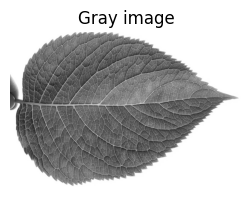

In [8]:
show_image(gray_image,"Gray image",cmap="gray")

In [18]:
import numpy as np
from scipy.ndimage import convolve
def laplacian_of_gaussian_kernel(ksize, sigma):
    ax = np.arange(-ksize//2 + 1, ksize//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    norm = (xx**2 + yy**2 - 2*sigma**2) / (sigma**4)
    kernel = norm * np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    kernel -= kernel.mean()  # Normalize
    return kernel

In [21]:
log_kernel = laplacian_of_gaussian_kernel(ksize=9, sigma=1.0)
log_result = convolve(gray_image, log_kernel)

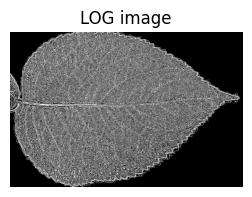

In [23]:
show_image(log_result,"LOG image",cmap="gray")